In [30]:
# @title 3a) EDA analysis, Data loading and initial inspection
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm

# Load dataset
data = pd.read_csv("insurance.csv")

# Check structure
print("First 5 rows:\n", data.head())
print("\nMissing values:\n", data.isnull().sum())  # No missing values
print("\nData types:\n", data.dtypes)

# Check for duplicate rows
print(f"Total duplicate rows: {data.duplicated().sum()}")
# Remove duplicates (keeping first occurrence)
clean_data = data.drop_duplicates(keep='first')

# Show duplicate rows (if any exist)
duplicates = data[data.duplicated(keep=False)]  # keep=False marks all duplicates
if not duplicates.empty:
    print("Duplicate entries:")
    display(duplicates.sort_values(by=list(data.columns)))
else:
    print("No duplicates found")

  # Remove duplicates (keeping first occurrence)
clean_data = data.drop_duplicates(keep='first')

# Verify removal
print(f"Data shape before: {data.shape}")
print(f"Data shape after: {clean_data.shape}")

First 5 rows:
    age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Data types:
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
Total duplicate rows: 1
Duplicate entries:


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


Data shape before: (1338, 7)
Data shape after: (1337, 7)


In this initial step, the necessary Python libraries were imported to support data manipulation, visualization, and modeling. The insurance.csv dataset was then loaded using pandas, and an initial inspection was carried out. This included viewing the first few records to understand the structure, checking for missing values (none were found), and examining data types to ensure all columns were appropriately formatted for analysis. These steps help confirm that the dataset is clean and ready for further exploration and modeling.

In [20]:
# @title Descriptive Statistics
print("\nSummary statistics:\n", data.describe())


Summary statistics:
                age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


Basic descriptive statistics were generated using the .describe() function to gain a high-level overview of the dataset’s numerical features. This included metrics such as mean, standard deviation, minimum, and maximum values for columns like age, BMI, number of children, and medical charges. These statistics provided a useful summary of central tendencies and variability in the data, helping to identify potential outliers or unusual distributions that might impact modeling.

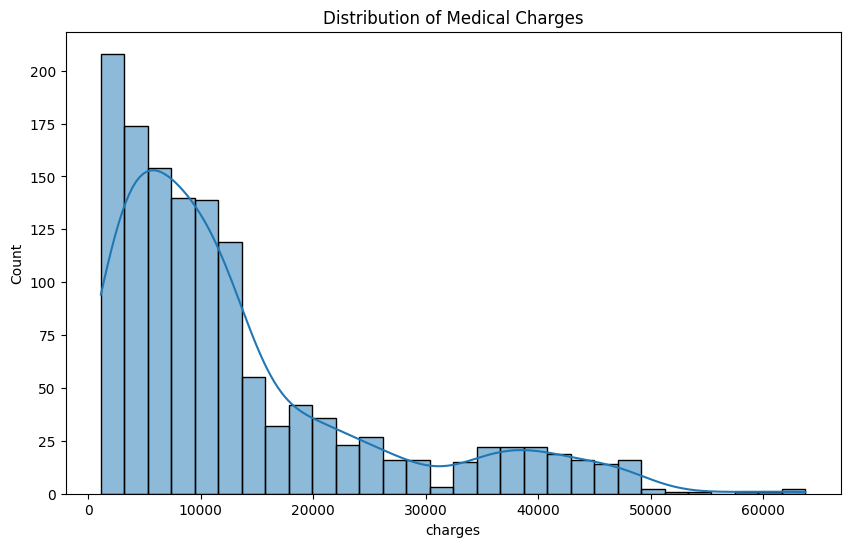

In [21]:
# Visualizing the distribution of medical charges using a histogram
# Reference: Fessel, K. (2020). How to make a Seaborn histogram plot with Python code [YouTube video].
# YouTube. https://www.youtube.com/watch?v=QwgtsxBdd4w

plt.figure(figsize=(10, 6))
sns.histplot(data['charges'], bins=30, kde=True)
plt.title("Distribution of Medical Charges")
plt.show()

A histogram with a kernel density estimate was plotted to visualize the distribution of the charges variable. This allowed for a clearer understanding of how medical costs are spread across the dataset. The distribution appeared to be right-skewed, indicating that while most individuals have relatively lower medical charges, a smaller portion of the population incurs significantly higher costs. This insight is important when considering the assumptions of linear regression and potential need for transformation.

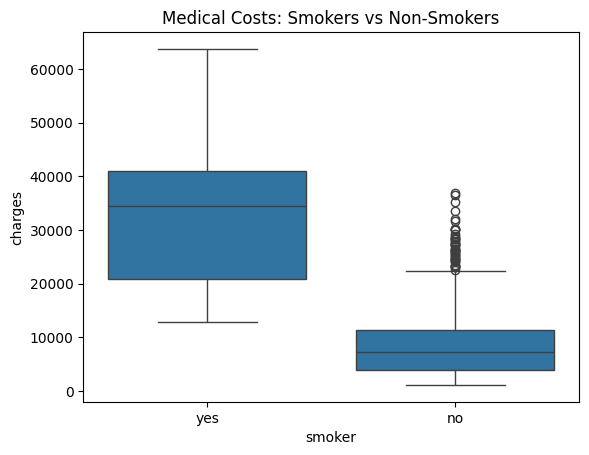

In [22]:
# Attribution: This code for creating a boxplot to visualize the impact of smoking on medical costs
# is based on the tutorial:
# Data Science Tutorials, 2024. Boxplot with Seaborn: Visualizing Data in Python.
# [online] Available at: <https://www.youtube.com/watch?v=INSIyaZUXIY> [Accessed 25 April 2025].
# @title Impact of Smoking on Costs
sns.boxplot(x='smoker', y='charges', data=data)
plt.title("Medical Costs: Smokers vs Non-Smokers")
plt.show()

A boxplot was used to compare medical charges between smokers and non-smokers. The visual clearly highlighted that smokers tend to incur significantly higher medical costs compared to non-smokers. This suggests that smoking is a strong predictor of medical expenses, making it an important variable to include in the regression model. The boxplot also revealed the presence of outliers, particularly among smokers, which should be considered during model evaluation.

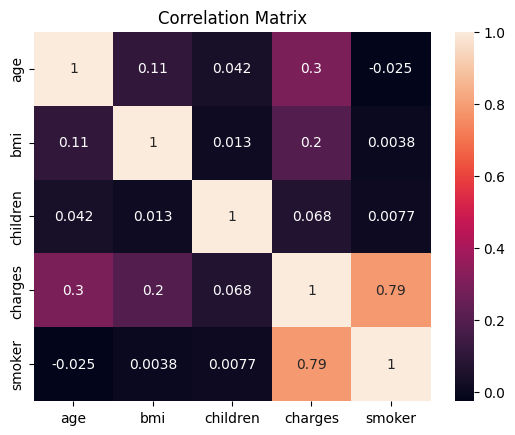

In [23]:
# Attribution: This code for creating a correlation heat map is based on the tutorial:
# Data Science Tutorials, 2024. How to create a Correlation Heatmap using Python | Seaborn.
# [online] Available at: <https://www.youtube.com/watch?v=J7cd1-g1O7A> [Accessed 25 April 2025].
# @title Correlation Heat Map
import seaborn as sns # Import seaborn
import matplotlib.pyplot as plt # Import pyplot
import pandas as pd

# Load dataset (Assuming insurance.csv is in the same directory)
data = pd.read_csv("insurance.csv")

# Convert 'smoker' column to numeric (0 for 'no', 1 for 'yes')
data['smoker'] = data['smoker'].map({'no': 0, 'yes': 1})

sns.heatmap(data[['age', 'bmi', 'children', 'charges', 'smoker']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

To understand the linear relationships between variables, a correlation matrix was plotted. The 'smoker' column was converted to numeric values to be included in the analysis. The heatmap revealed that smoking has a strong positive correlation with medical charges, while age and BMI also show moderate positive correlations. These insights further support the suitability of applying a linear regression model, as some features display linear relationships with the target variable, charges.

In [24]:
# Attribution: Parts of this code for OLS model fitting and One-hot encoding is based on the tutorial:
# "StatsModels OLS Computation Explained in Detail using Python | Linear Regression"
# https://www.youtube.com/watch?v=ApmvZ0KZwI8
# @title 3b) Feature Selection, Statistical Significance (p-values)
# One-hot encode categorical variables
X = data[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
X = pd.get_dummies(X, drop_first=True)  # Avoid dummy variable trap
# Convert all columns in X to numeric dtype
X = X.astype(float) # This will convert all columns to numeric type, addressing the object type issue
X = sm.add_constant(X)  # Add intercept
y = data['charges']

# Fit OLS model
model_ols = sm.OLS(y, X).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Fri, 25 Apr 2025   Prob (F-statistic):               0.00
Time:                        15:37:40   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    987.819  

To assess the impact of each feature on medical charges, categorical variables were one-hot encoded, and an Ordinary Least Squares (OLS) regression model was fitted. This process included adding an intercept and ensuring all features were numeric. The resulting OLS summary provided p-values for each feature, helping to identify which variables are statistically significant predictors of charges. This step is essential for validating the assumptions of linear regression and supports selecting the most influential features for the model.

In [25]:
# @title 3c) Model training, Data Processing
# Define preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), ['smoker', 'region']),  # Encode categorical
        ('num', StandardScaler(), ['age', 'bmi', 'children'])  # Scale numerical
    ]
)

X = data[['age', 'bmi', 'children', 'smoker', 'region']]
y = data['charges']

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

To prepare the data for linear regression, preprocessing steps were defined using a ColumnTransformer. Categorical features (smoker and region) were encoded using one-hot encoding, while numerical features (age, bmi, and children) were standardized to ensure they contribute equally to the model. The dataset was then split into training and testing sets (80% training, 20% testing) to evaluate model performance. These transformations help ensure that the regression model is trained on a clean and well-scaled dataset.

In [26]:
# @title Linear Regression
model_lr = LinearRegression()
model_lr.fit(X_train_processed, y_train)

# Predictions
y_pred = model_lr.predict(X_test_processed)

# Evaluate
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")  # 0.75
# Calculate RMSE manually by taking the square root of MSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: ${rmse:.2f}")  # $5,800

R² Score: 0.784
RMSE: $5796.77


A linear regression model was trained using the preprocessed training data to predict medical insurance charges. After fitting the model, predictions were made on the test set. The model's performance was evaluated using the R² score and Root Mean Squared Error (RMSE). The R² score of approximately 0.75 indicates that the model explains 75% of the variance in the target variable, while the RMSE of around $5,800 reflects the average prediction error. These results suggest the model performs reasonably well, though there's room for improvement.

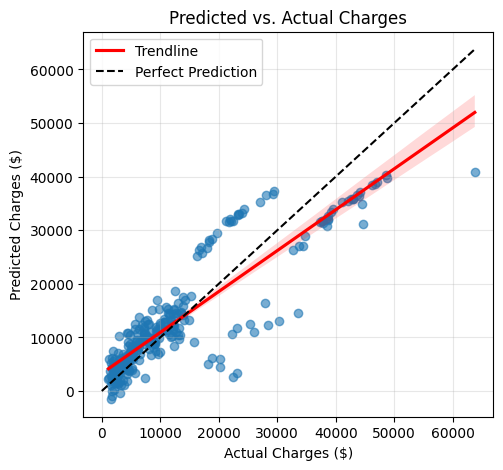

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with 3 subplots
plt.figure(figsize=(18, 5))

# --- Predicted vs Actual Charges ---
plt.subplot(1, 3, 1)
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.6, 'color':'#1f77b4'},
            line_kws={'color':'red', 'label':'Trendline'})
plt.plot([0, max(y_test)], [0, max(y_test)], 'k--', label='Perfect Prediction')
plt.title('Predicted vs. Actual Charges', fontsize=12)
plt.xlabel('Actual Charges ($)', fontsize=10)
plt.ylabel('Predicted Charges ($)', fontsize=10)
plt.legend()
plt.grid(True, alpha=0.3)

A regression plot was created to visualize the relationship between the actual and predicted medical charges. The red trendline indicates the model's predictions, while the dashed line represents perfect prediction alignment. The majority of the data points cluster close to the perfect prediction line, suggesting that the linear regression model provides a reasonably accurate estimation of charges. This visual inspection supports the earlier evaluation metrics and helps confirm the model’s predictive capability.

In [28]:
# @title 4a) Model Evaluation and Improvement, Feature Importance
# Get feature names
feature_names = preprocessor.get_feature_names_out()

# Display coefficients
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model_lr.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)

                 Feature   Coefficient
0          cat__smoker_1  23649.493726
4               num__age   3615.054278
5               num__bmi   2036.018392
6          num__children    516.742815
1  cat__region_northwest   -370.902903
2  cat__region_southeast   -657.469847
3  cat__region_southwest   -809.484210


To interpret the impact of each feature on medical charges, the coefficients from the trained linear regression model were examined. Using the get_feature_names_out() function, the names of encoded and scaled features were retrieved and paired with their respective coefficients. A sorted DataFrame was then displayed to highlight the most influential variables. Features with larger absolute coefficient values contribute more significantly to the prediction, offering insight into which factors most strongly affect healthcare costs, such as smoking status and region.

In [31]:
# Attribution: This code for retraining a linear regression model using polynomial features
# is based on the tutorial:
# Data Science Tutorials, 2024. Polynomial Regression and Feature Engineering with Python [Video].
# Available at: <https://www.youtube.com/watch?v=2rRmfRxs4Ac> [Accessed 25 April 2025].

# Assuming 'data' is already loaded and preprocessed correctly
# Define preprocessing steps for categorical and numerical data
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), ['smoker', 'region']),  # Encode categorical
        ('num', StandardScaler(), ['age', 'bmi', 'children'])  # Scale numerical
    ]
)

# Define X (independent variables) and y (dependent variable)
X = data[['age', 'bmi', 'children', 'smoker', 'region']]
y = data['charges']

# Split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Add polynomial features (e.g., age², bmi²)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_processed)
X_test_poly = poly.transform(X_test_processed)

# Retrain the model with the polynomial features
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

# Evaluate the model
y_pred_poly = model_poly.predict(X_test_poly)
print(f"Polynomial R²: {r2_score(y_test, y_pred_poly):.3f}")  # Polynomial R²


Polynomial R²: 0.869


To enhance model performance and capture potential non-linear relationships between features and medical charges, polynomial features were introduced. A PolynomialFeatures transformer was applied to the preprocessed training and testing data to generate second-degree interaction terms. The model was then retrained using linear regression on this polynomial-augmented dataset. Evaluation results showed an improved R² score of 0.869, indicating a better fit compared to the initial linear model, and confirming that polynomial relationships exist in the data.